<a href="https://colab.research.google.com/github/RachmadAprisandhy/PembelajaranMesin/blob/main/JS06/JS06_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import database

In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
	# Import Required Libraries
	from pathlib import Path
	import matplotlib.image as mpimg
	import matplotlib.pyplot as plt
	import cv2
	import random
	import numpy as np
	import pandas as pd

In [22]:
train_dir = "/content/drive/MyDrive/Pembelajaran mesin/images/images/training"
test_dir = "/content/drive/MyDrive/Pembelajaran mesin/images/images/test"

print("Training:", train_dir)
print("Test:", test_dir)

Training: /content/drive/MyDrive/Pembelajaran mesin/images/images/training
Test: /content/drive/MyDrive/Pembelajaran mesin/images/images/test


1. Load Data dan Visualisasikan

In [23]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        if not dir.is_dir():
            continue

        label = dir.name

        for file in dir.rglob('*'):
            if not file.is_file():
                continue

            if file.name.startswith('.'):
                continue

            if file.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue

            img = mpimg.imread(file)

            if img is not None:
                img_list.append((img, label))

    return img_list

In [24]:
print("Load gambar training")
train_img = load_dataset(train_dir)

print("Jumlah data training:", len(train_img))

Load gambar training
Jumlah data training: 240


pengecekan pada salah satu data pada list

In [25]:
	# Check the first data
	# It should be a tuple consist of arrays of image and image labels
	train_img[0]

(array([[[139, 183, 232],
         [141, 185, 234],
         [141, 185, 234],
         ...,
         [137, 179, 229],
         [138, 180, 230],
         [138, 180, 230]],
 
        [[141, 185, 234],
         [144, 188, 237],
         [144, 188, 237],
         ...,
         [141, 183, 233],
         [141, 183, 233],
         [141, 183, 233]],
 
        [[137, 181, 230],
         [140, 184, 233],
         [140, 184, 233],
         ...,
         [138, 180, 230],
         [138, 180, 230],
         [139, 181, 231]],
 
        ...,
 
        [[131, 128, 109],
         [116, 113,  94],
         [127, 124, 107],
         ...,
         [ 92,  90,  93],
         [ 92,  90,  93],
         [ 92,  90,  93]],
 
        [[128, 123, 104],
         [102,  97,  78],
         [115, 110,  91],
         ...,
         [ 93,  93,  95],
         [ 93,  93,  95],
         [ 93,  93,  95]],
 
        [[122, 117,  98],
         [100,  95,  76],
         [112, 107,  88],
         ...,
         [ 93,  93,  95],
  

Cek ukuran gambar secara acak

In [26]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_img))

	# Check img size
	print(f'Image {pick_random}')
	print(train_img[pick_random][0].shape)

Image 129
(737, 1024, 3)


Tampilkan gambar untuk inspeksi secara visual. Buatlah fungsi untuk membantu memvisualkan gambar

In [27]:
	# Function to Visualize
	def random_img_viz(img_list):
	    rand_num = np.random.randint(0, len(img_list))

	    img = img_list[rand_num][0]
	    label = img_list[rand_num][1]
	    label_str = 'day' if label == 1 else 'night'

	    plt.imshow(img)
	    print(f'Shape\t: {img.shape}')
	    print(f'Label\t: {label}')

lakukan visualisasi gambar

Shape	: (469, 640, 3)
Label	: night


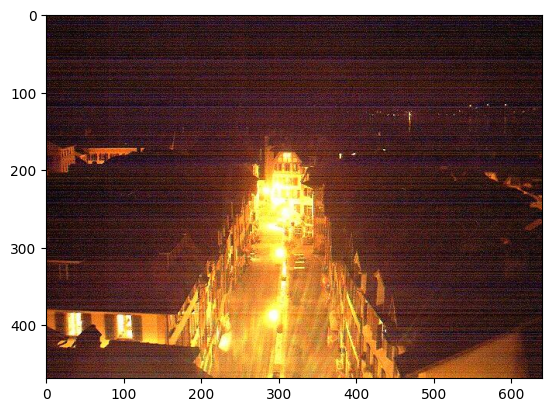

In [28]:
random_img_viz(train_img)

3. pra pengolahan data

fungsi menstandardkan gambar

In [29]:
	def standarized_input(image):
	    # resize to w: 1100, h:600
	    std_img = cv2.resize(image, (1100,600))

	    return std_img

buatlah fungsi untuk kebutuhan encoding label.

In [30]:
	def label_encoder(label):
	    # Encode the label
	    # day as 1; night as 0
	    num_val = 0

	    if(label == 'day'):
	        num_val = 1

	    return num_val

buatlah fungsi untuk melakukan kedua hal tersebut secara sekaligus untuk semua gambar dalam list.

In [31]:
	def preprocess(img_list):
	    std_img_list = []

	    for item in img_list:
	        image = item[0]
	        label = item[1]

	        # Standarized the image
	        std_img = standarized_input(image)

	        # Create the label
	        img_label = label_encoder(label)

	        std_img_list.append((std_img, img_label))

	    return std_img_list

Lakukan pra pengolahan data pada data training.

In [32]:
train_std_img_list = preprocess(train_img)

Lakukan pengecekan ukuran gambar secara acak.

In [33]:
	# Random size checking
	pick_random = np.random.randint(0, len(train_std_img_list))

	# Check img size
	print(f'Image {pick_random}')
	print(train_std_img_list[pick_random][0].shape)

Image 36
(600, 1100, 3)


cek

Shape	: (600, 1100, 3)
Label	: 1


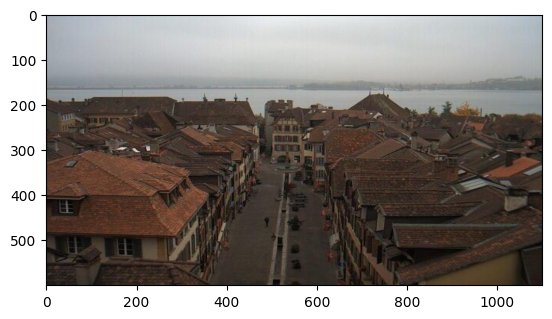

In [36]:
random_img_viz(train_std_img_list)

4. ekstraksi fitur

Buatlah fungsi berikut untuk mendapatkan nilai rata-rata tingkat kecerahan.

In [37]:
	# Get feature based on average brightness using HSV colorspace
	def avg_brightness(image):
	    # Convert image to HSV
	    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

	    # Calculate the avg of brightness
	    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
	    area = image.shape[0] * image.shape[1]
	    avg = sum_brightness / area

	    return avg

Lakukan pengecekan pada gambar secara acak.

Image 118
Avg Brighness: 157.3603


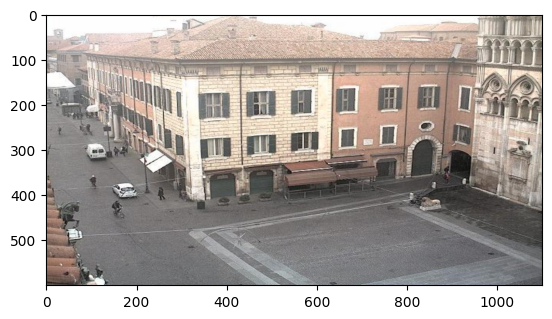

In [38]:
	# Check on random image
	rand_img = np.random.randint(0, len(train_std_img_list))

	feature_img = train_std_img_list[rand_img][0]

	avg_img = avg_brightness(feature_img)

	print(f'Image {rand_img}')
	print(f'Avg Brighness: {avg_img:.4f}')
	plt.imshow(feature_img)

5. Klasifikasi dengan Metode Threshold

In [39]:
	def predict_label(img, threshold):
	    # Computer average brightness
	    avg = avg_brightness(img)
	    pred = 0

	    # Predict the label based on user defined threshold
	    if avg > threshold:
	        pred = 1

	    return pred

Lakukan pengecekan prediksi secara acak pada data training

Image 67
Actual label: 1
Predicted label: 0


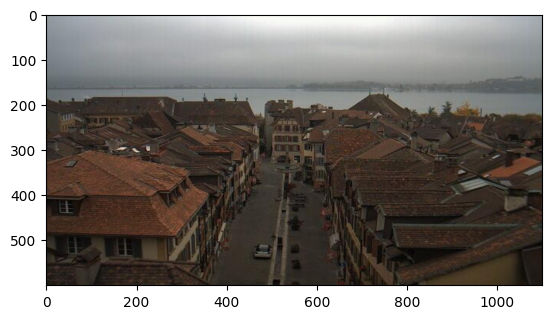

In [40]:
	# Test the classifier on train data
	rand_img = np.random.randint(0, len(train_std_img_list))

	pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

	# Evaluate
	print(f'Image {rand_img}')
	print(f'Actual label: {train_std_img_list[rand_img][1]}')
	print(f'Predicted label: {pred}')
	plt.imshow(train_std_img_list[rand_img][0])

6. Evaluasi Manual

In [41]:
	def evaluate(img_list, threshold):
	    miss_labels = []

	    for file in img_list:
	        # Get the ground truth / correct label
	        img = file[0]
	        label = file[1]

	        # Get prediction
	        pred_label = predict_label(img, threshold)

	        # Compare ground truth and pred
	        if pred_label != label:
	            miss_labels.append((img, pred_label, label))

	    total_img = len(img_list)
	    corr_pred = total_img - len(miss_labels)
	    accuracy = corr_pred / total_img

	    print(f'Accuracy: {accuracy:.4f}')

Lakukan evaluasi pada data training dengan nilai ambang batas 120.

In [42]:
	# Evaluate on train data
	evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


kita akan melakukan evaluasi pada data testing. Namun sebelumnya, data testing harus diperlakukan sama dengan data training dalam konteks pra progolahan data dan ekstraksi fitur.

In [45]:
print("Load gambar test")
test_img = load_dataset(test_dir)

print("Jumlah data test:", len(test_img))

Load gambar test
Jumlah data test: 160


preprocessing data

In [46]:
test_std_img_list = preprocess(test_img)

print("Jumlah data test setelah preprocessing:", len(test_std_img_list))

Jumlah data test setelah preprocessing: 160


cek ukuran gambar

In [47]:
# Random size checking
pick_random = np.random.randint(0, len(test_std_img_list))

print("Image", pick_random)
print("Shape:", test_std_img_list[pick_random][0].shape)

Image 112
Shape: (600, 1100, 3)


cek visualisasi

Shape	: (593, 800, 3)
Label	: day


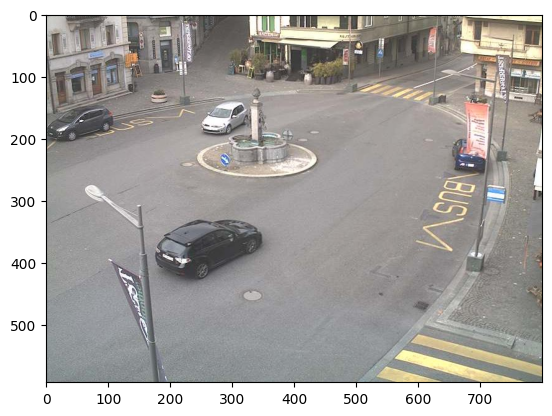

In [48]:
random_img_viz(test_img)

Shape	: (600, 1100, 3)
Label	: 0


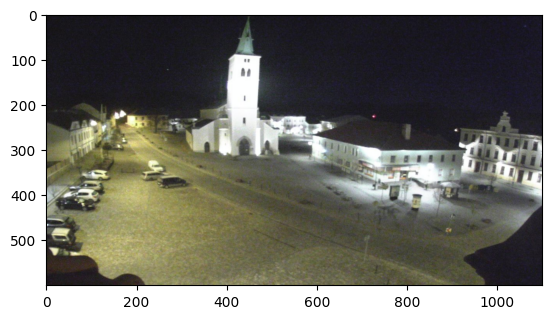

In [49]:
random_img_viz(test_std_img_list)

In [50]:
	def evaluate(img_list, threshold):
	    miss_labels = []

	    for file in img_list:
	        # Get the ground truth / correct label
	        img = file[0]
	        label = file[1]

	        # Get prediction
	        pred_label = predict_label(img, threshold)

	        # Compare ground truth and pred
	        if pred_label != label:
	            miss_labels.append((img, pred_label, label))

	    total_img = len(img_list)
	    corr_pred = total_img - len(miss_labels)
	    accuracy = corr_pred / total_img

	    print(f'Accuracy: {accuracy:.4f}')

In [51]:
	# Evaluate on train data
	evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


Klasifikasi dengan SVM

Langkah 4 Alternatif - Membuat Feature Vectors.


In [52]:
	# Create function to extract feature for every images and stored in tabular data
	# Stored in Pandas dataframe
	def extract_avg_bright_feature(img_list):
	    avg_list = []
	    labels = []

	    for img in img_list:
	        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
	        img_label = img[1] # Get the image label

	        avg_list.append(img_avg)
	        labels.append(img_label)

	    # Stack data in columcular way
	    data = np.column_stack((avg_list, labels))
	    # Create a Pandas dataframe
	    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

	    return df

Cek hasilnya pada data training,

In [53]:
	# Extract feature on train data
	train_avg_img = extract_avg_bright_feature(train_std_img_list)
	print(f'Shape: {train_avg_img.shape}')
	train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,195.107926,1.0
1,111.650758,1.0
2,181.735806,1.0
3,110.252348,1.0
4,189.626658,1.0


In [54]:
	# Do the same thing on test data
	test_avg_img = extract_avg_bright_feature(test_std_img_list)
	print(f'Shape: {test_avg_img.shape}')
	test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,25.617185,0.0
1,87.177233,0.0
2,26.358703,0.0
3,13.861829,0.0
4,89.018533,0.0


5. Buat Model SVM

In [55]:
	# import requied library
	from sklearn.svm import SVC

	# Split data and label
	X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
	y_train = train_avg_img.iloc[:,1]
	X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
	y_test = test_avg_img.iloc[:,1]

	model = SVC()
	model.fit(X_train, y_train)

SVC()

6. Evaluasi

In [56]:
	from sklearn.metrics import accuracy_score

	# Make a prediction on train data
	y_train_pred = model.predict(X_train)

	# Get the accuracy on train data
	acc_train = accuracy_score(y_train, y_train_pred)

	# Make a prediction on test data
	y_test_pred = model.predict(X_test)

	# Get the accuracy on test data
	acc_test = accuracy_score(y_test, y_test_pred)

	# Print Eval Result
	print(f'Accuracy on train: {acc_train}')
	print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
